In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import os
import warnings
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import pymannkendall as mk
warnings.filterwarnings('ignore')

In [37]:
df = pd.read_csv('data\\cleaned_data.csv', parse_dates=['time'], index_col='time')
df

,day,month,year,hour,pm10 (μg/m³),pm2_5 (μg/m³),carbon_monoxide (μg/m³),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),ozone (μg/m³),uv_index_clear_sky (),uv_index (),dust (μg/m³),aerosol_optical_depth ()
time,,,,,,,,,,,,,,
2022-08-04 07:00:00,4,8,2022,7,14.4,10.1,196.0,2.0,0.6,35.0,1.20,1.05,0.0,0.09
2022-08-04 08:00:00,4,8,2022,8,11.1,7.8,186.0,1.6,0.5,38.0,3.55,3.05,0.0,0.09
2022-08-04 09:00:00,4,8,2022,9,9.4,6.5,172.0,1.1,0.4,41.0,6.95,5.95,0.0,0.08
2022-08-04 10:00:00,4,8,2022,10,10.0,7.0,160.0,0.7,0.4,47.0,10.45,8.50,0.0,0.09
2022-08-04 11:00:00,4,8,2022,11,12.1,8.5,161.0,0.7,0.5,51.0,12.75,10.10,0.0,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-26 19:00:00,26,7,2026,19,12.9,10.5,291.0,3.3,1.5,65.0,0.00,0.00,4.0,0.21
2026-07-26 20:00:00,26,7,2026,20,12.7,10.6,320.0,3.6,1.5,59.0,0.00,0.00,4.0,0.20
2026-07-26 21:00:00,26,7,2026,21,12.4,10.4,343.0,4.0,1.6,50.0,0.00,0.00,3.0,0.18


##### Chuẩn hóa tên cột cho các chỉ số không khí

In [38]:
# Chuẩn hóa tên cột: loại bỏ đơn vị đo
rename_mapping = {
    'pm10 (μg/m³)': 'PM10',
    'pm2_5 (μg/m³)': 'PM2.5',
    'carbon_monoxide (μg/m³)': 'Carbon Monoxide',
    'nitrogen_dioxide (μg/m³)': 'Nitrogen Dioxide',
    'sulphur_dioxide (μg/m³)': 'Sulphur Dioxide',
    'ozone (μg/m³)': 'Ozone',
    'uv_index_clear_sky ()': 'UV Index Clear Sky',
    'uv_index ()': 'UV Index',
    'dust (μg/m³)': 'Dust',
    'aerosol_optical_depth ()': 'Aerosol Optical Depth'
}

df = df.rename(columns=rename_mapping)
print("Tên cột đã được chuẩn hóa:")
print(df.columns.tolist())

Tên cột đã được chuẩn hóa:
['day', 'month', 'year', 'hour', 'PM10', 'PM2.5', 'Carbon Monoxide', 'Nitrogen Dioxide', 'Sulphur Dioxide', 'Ozone', 'UV Index Clear Sky', 'UV Index', 'Dust', 'Aerosol Optical Depth']


In [39]:
describe_table = df.describe().T.iloc[4:, :]
describe_table

,count,mean,std,min,25%,50%,75%,max
PM10,34865.0,19.012815,9.567588,0.20,12.30,17.40,24.30,95.5
PM2.5,34865.0,13.237551,6.863580,0.10,8.50,11.90,16.50,66.1
Carbon Monoxide,34865.0,243.515646,109.876442,59.00,169.00,218.00,287.00,1185.0
Nitrogen Dioxide,34865.0,2.681962,2.606592,0.00,1.20,1.90,3.10,25.8
Sulphur Dioxide,34865.0,1.726172,1.106868,0.00,1.00,1.50,2.20,12.2
Ozone,34865.0,80.201778,28.781749,5.00,58.00,78.00,98.00,246.0
UV Index Clear Sky,34865.0,2.560040,3.881229,0.00,0.00,0.00,4.30,14.3
UV Index,34865.0,2.005005,3.202601,0.00,0.00,0.00,3.20,13.6
Dust,34865.0,0.475635,1.648559,0.00,0.00,0.00,0.00,39.0
Aerosol Optical Depth,34865.0,0.242209,0.152784,0.01,0.15,0.21,0.28,2.3


##### Correlation Heatmap: Mối tương quan giữa các thuộc tính Air Quality

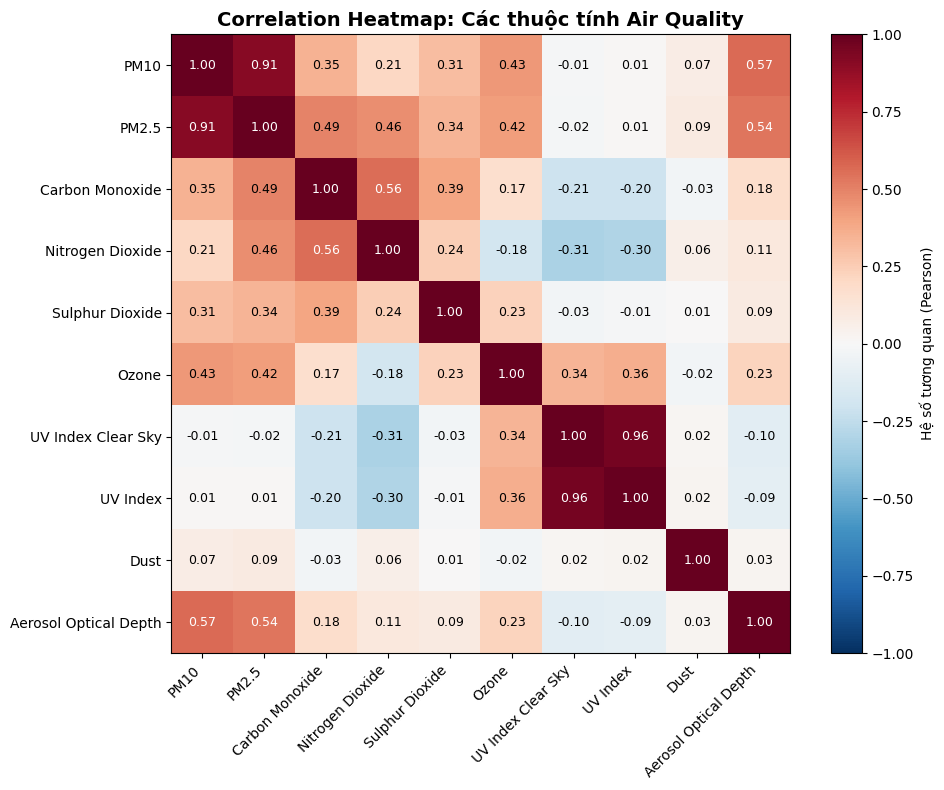

In [40]:
air_quality_cols = ['PM10', 'PM2.5', 'Carbon Monoxide', 'Nitrogen Dioxide', 'Sulphur Dioxide',
                     'Ozone', 'UV Index Clear Sky', 'UV Index', 'Dust', 'Aerosol Optical Depth']
corr_matrix = df[air_quality_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(air_quality_cols)))
ax.set_yticks(range(len(air_quality_cols)))
ax.set_xticklabels(air_quality_cols, rotation=45, ha='right')
ax.set_yticklabels(air_quality_cols)

for i in range(len(air_quality_cols)):
    for j in range(len(air_quality_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black', fontsize=9)

plt.colorbar(im, ax=ax, label='Hệ số tương quan (Pearson)')
plt.title('Correlation Heatmap: Các thuộc tính Air Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### Vẽ biểu đồ đường (Lineplot) cho PM2.5

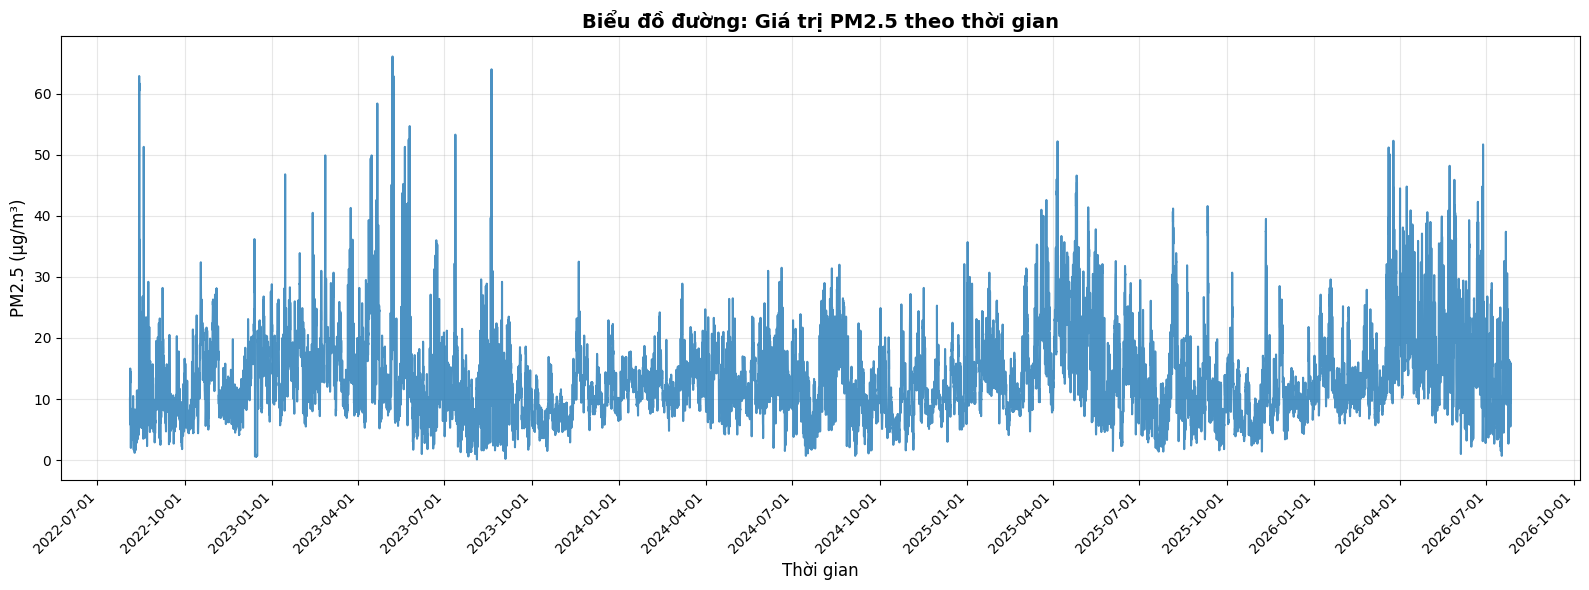

In [41]:
plt.figure(figsize=(16, 6))
plt.plot(df.index, df['PM2.5'], linewidth=1.5, color='#1f77b4', alpha=0.8)

# Format trục X để hiển thị thời gian
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Hiển thị mỗi 3 tháng
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Format: YYYY-MM-DD

# Rotate xticks để không bị đè
plt.xticks(rotation=45, ha='right')

plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.title('Biểu đồ đường: Giá trị PM2.5 theo thời gian', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Vẽ Moving Average để phát hiện xu hướng

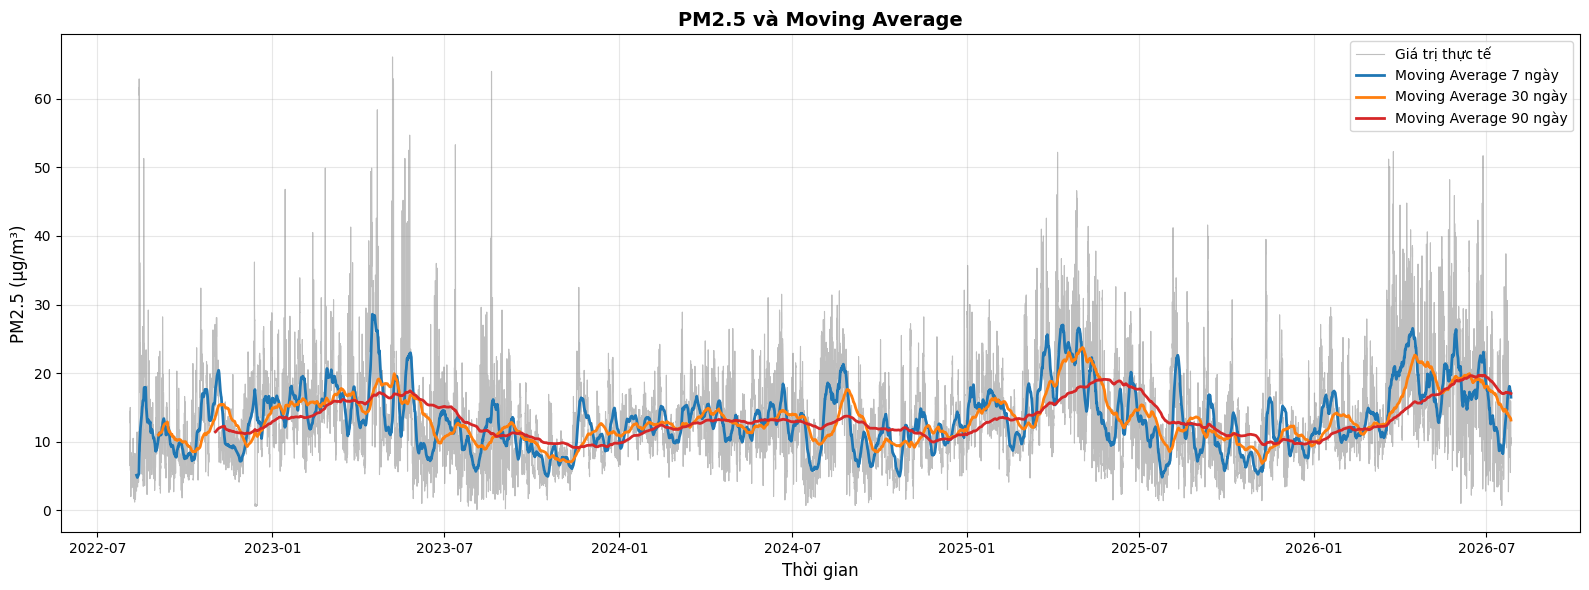

In [42]:
# Sắp xếp dữ liệu theo thời gian
df_sorted = df.sort_index()

# Tính moving average với các window khác nhau (dữ liệu theo giờ nên nhân 24 để đúng đơn vị ngày)
ma_7 = df_sorted['PM2.5'].rolling(window=24*7).mean()      # 7 ngày
ma_30 = df_sorted['PM2.5'].rolling(window=24*30).mean()    # 30 ngày
ma_90 = df_sorted['PM2.5'].rolling(window=24*90).mean()    # 90 ngày

plt.figure(figsize=(16, 6))
plt.plot(df_sorted.index, df_sorted['PM2.5'], label='Giá trị thực tế', linewidth=0.8, alpha=0.5, color='gray')
plt.plot(df_sorted.index, ma_7, label='Moving Average 7 ngày', linewidth=2, color='#1f77b4')
plt.plot(df_sorted.index, ma_30, label='Moving Average 30 ngày', linewidth=2, color='#ff7f0e')
plt.plot(df_sorted.index, ma_90, label='Moving Average 90 ngày', linewidth=2, color='#d62728')

plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.title('PM2.5 và Moving Average', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Phân phối PM2.5 (Histogram & KDE)

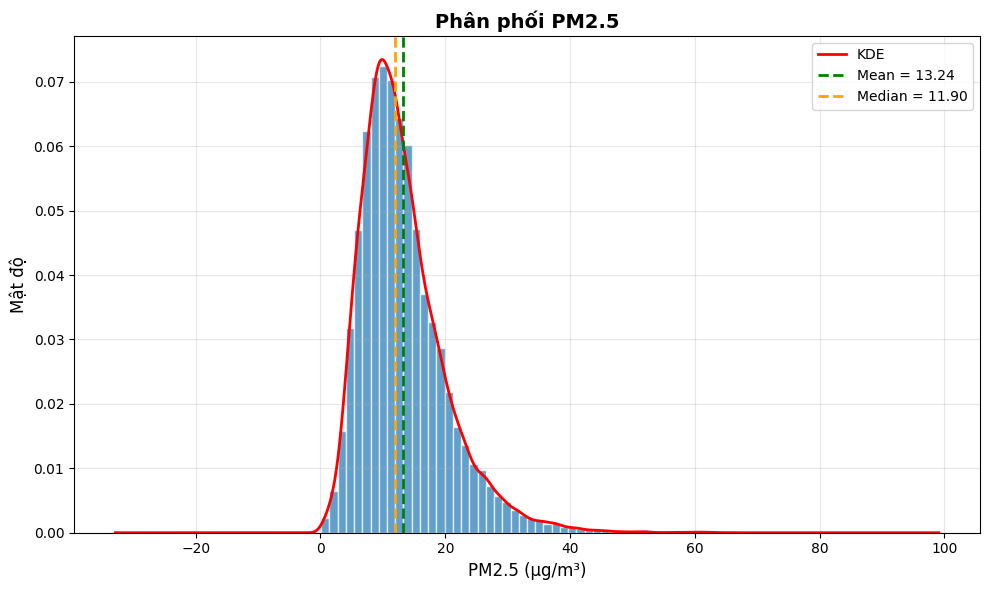

Skewness: 1.3720 -> Lệch phải (right-skewed, đuôi dài về giá trị cao)
Kurtosis (excess): 3.4144 -> Đuôi dày hơn phân phối chuẩn (nhiều outlier hơn)


In [43]:
pm25 = df_sorted['PM2.5'].dropna()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(pm25, bins=50, color='#1f77b4', alpha=0.7, edgecolor='white', density=True)
pm25.plot(kind='kde', ax=ax, color='red', linewidth=2, label='KDE')

ax.axvline(pm25.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean = {pm25.mean():.2f}')
ax.axvline(pm25.median(), color='orange', linestyle='--', linewidth=2, label=f'Median = {pm25.median():.2f}')

ax.set_xlabel('PM2.5 (µg/m³)', fontsize=12)
ax.set_ylabel('Mật độ', fontsize=12)
ax.set_title('Phân phối PM2.5', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

sk = stats.skew(pm25)
ku = stats.kurtosis(pm25)
print(f"Skewness: {sk:.4f} -> {'Lệch phải (right-skewed, đuôi dài về giá trị cao)' if sk > 0 else 'Lệch trái (left-skewed)'}")
print(f"Kurtosis (excess): {ku:.4f} -> {'Đuôi dày hơn phân phối chuẩn (nhiều outlier hơn)' if ku > 0 else 'Đuôi mỏng hơn phân phối chuẩn'}")

##### Phân phối PM2.5 theo từng năm (Violin Plot)

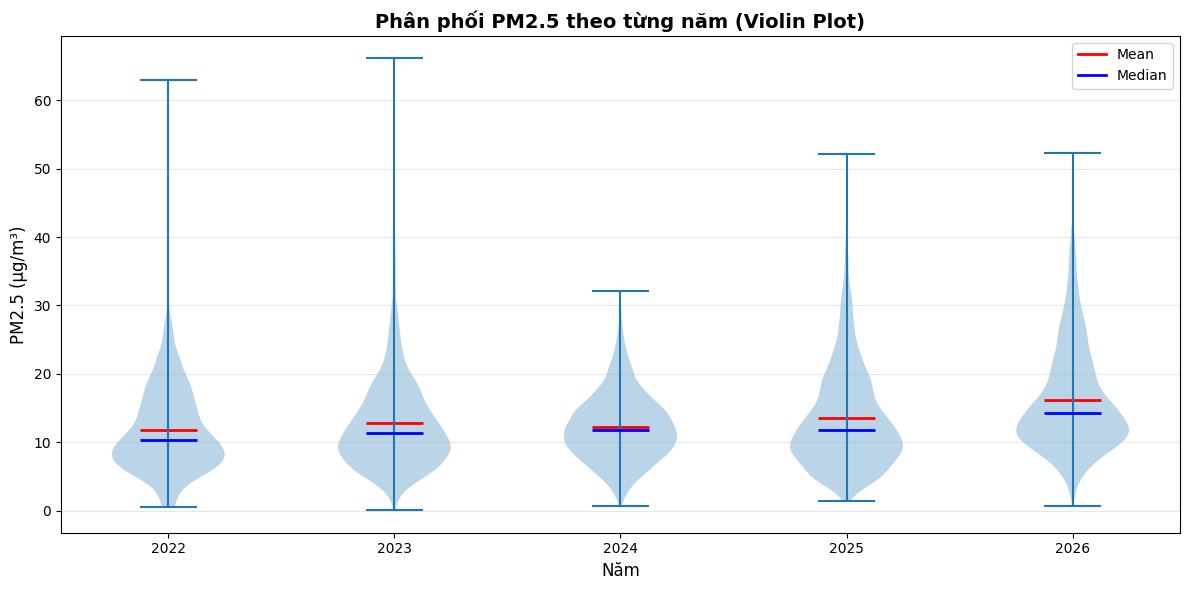

In [44]:
# Khác với bar chart trung bình theo năm đã có: đây cho thấy cả hình dạng phân phối
# (độ phân tán, độ lệch) thay đổi thế nào qua từng năm, không chỉ mỗi giá trị mean
years = sorted(df_sorted['year'].unique())
data_by_year = [df_sorted[df_sorted['year'] == y]['PM2.5'].dropna().values for y in years]

plt.figure(figsize=(12, 6))
parts = plt.violinplot(data_by_year, showmeans=True, showmedians=True)

# Tô màu riêng để phân biệt Mean và Median (mặc định 2 đường này trông giống hệt nhau)
parts['cmeans'].set_color('red')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('blue')
parts['cmedians'].set_linewidth(2)

# Thêm legend thủ công vì violinplot không tự sinh legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', linewidth=2, label='Mean'),
    Line2D([0], [0], color='blue', linewidth=2, label='Median'),
]
plt.legend(handles=legend_elements)

plt.xticks(range(1, len(years) + 1), [str(y) for y in years])
plt.xlabel('Năm', fontsize=12)
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.title('Phân phối PM2.5 theo từng năm (Violin Plot)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

##### Outlier / Threshold Exceedance theo chuẩn WHO & QCVN Việt Nam

Tổng số ngày có dữ liệu: 1453
Số ngày vượt ngưỡng WHO (15 µg/m³): 451 (31.0%)
Số ngày vượt ngưỡng QCVN Việt Nam (50 µg/m³): 0 (0.0%)


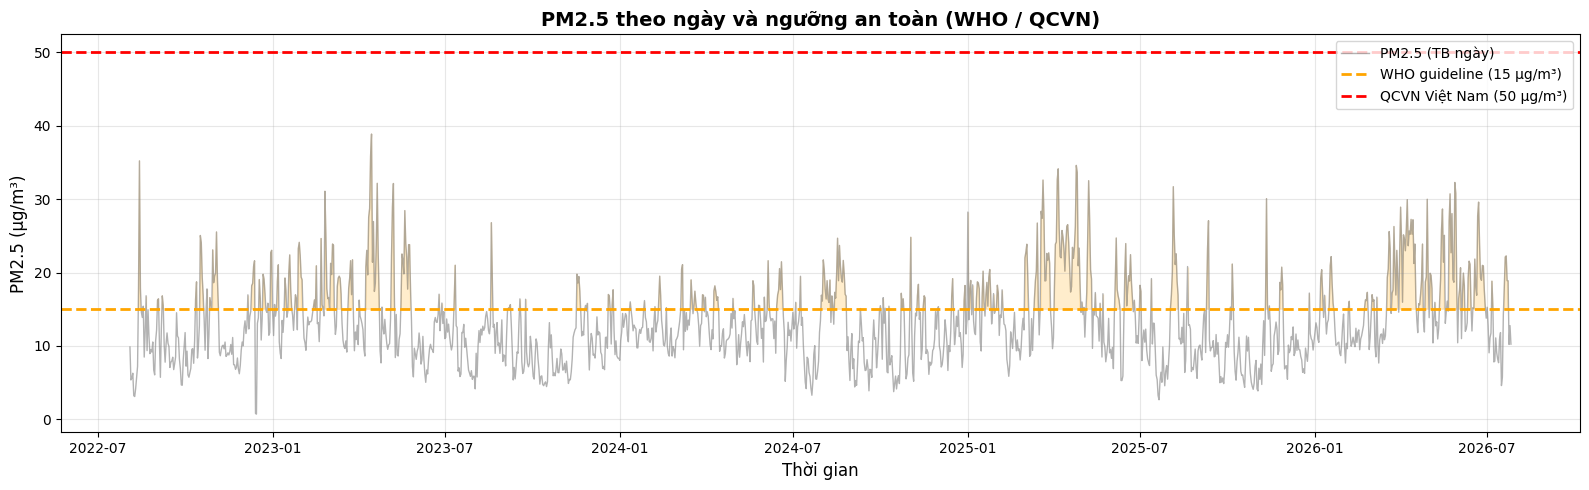

In [45]:
# Ngưỡng tham khảo cho PM2.5 trung bình 24h
who_guideline = 15  # WHO Air Quality Guideline 2021
qcvn_limit = 50      # QCVN 05:2013/BTNMT (Việt Nam)

daily_pm25 = df_sorted['PM2.5'].resample('D').mean().dropna()
total_days = len(daily_pm25)
exceed_who = (daily_pm25 > who_guideline).sum()
exceed_qcvn = (daily_pm25 > qcvn_limit).sum()

print(f"Tổng số ngày có dữ liệu: {total_days}")
print(f"Số ngày vượt ngưỡng WHO ({who_guideline} µg/m³): {exceed_who} ({exceed_who / total_days * 100:.1f}%)")
print(f"Số ngày vượt ngưỡng QCVN Việt Nam ({qcvn_limit} µg/m³): {exceed_qcvn} ({exceed_qcvn / total_days * 100:.1f}%)")

plt.figure(figsize=(16, 5))
plt.plot(daily_pm25.index, daily_pm25.values, color='gray', alpha=0.6, linewidth=1, label='PM2.5 (TB ngày)')
plt.axhline(who_guideline, color='orange', linestyle='--', linewidth=2, label=f'WHO guideline ({who_guideline} µg/m³)')
plt.axhline(qcvn_limit, color='red', linestyle='--', linewidth=2, label=f'QCVN Việt Nam ({qcvn_limit} µg/m³)')
plt.fill_between(daily_pm25.index, daily_pm25.values, who_guideline,
                  where=(daily_pm25.values > who_guideline), color='orange', alpha=0.2)

plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.title('PM2.5 theo ngày và ngưỡng an toàn (WHO / QCVN)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Seasonal Subseries Plot: PM2.5 theo từng tháng

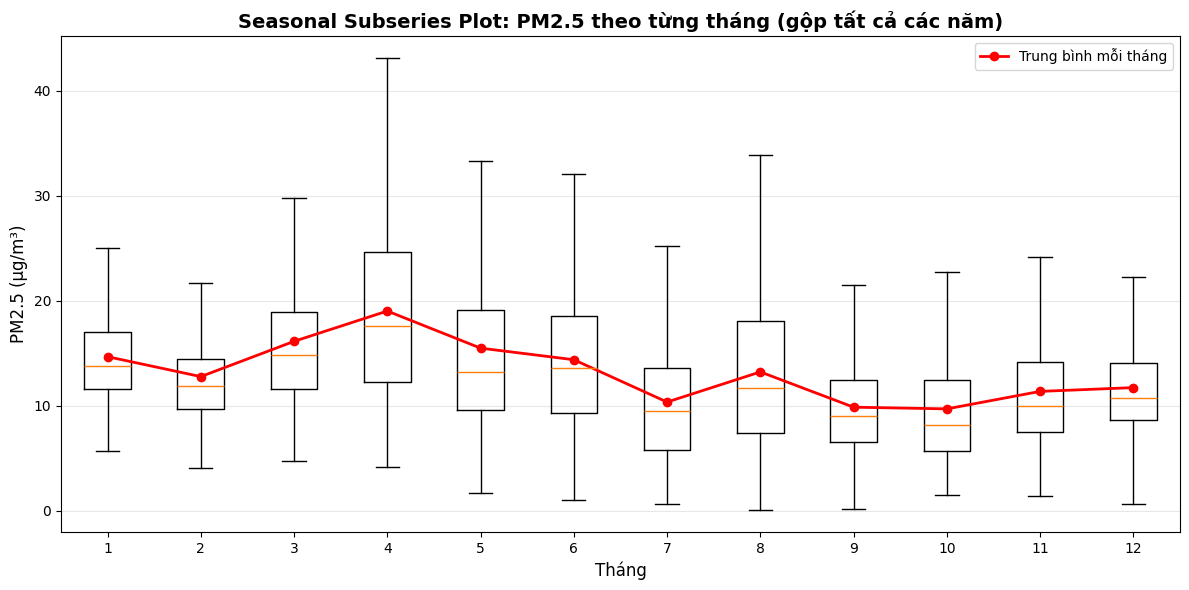

In [46]:
# Gom PM2.5 theo từng tháng (1-12), gộp dữ liệu của tất cả các năm cho mỗi tháng
months = range(1, 13)
data_by_month = [df_sorted[df_sorted['month'] == m]['PM2.5'].dropna().values for m in months]
month_means = [d.mean() for d in data_by_month]

plt.figure(figsize=(12, 6))
plt.boxplot(data_by_month, tick_labels=[str(m) for m in months], showfliers=False)
plt.plot(range(1, 13), month_means, color='red', marker='o', linewidth=2, label='Trung bình mỗi tháng')

plt.xlabel('Tháng', fontsize=12)
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.title('Seasonal Subseries Plot: PM2.5 theo từng tháng (gộp tất cả các năm)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

##### Autocorrelation (ACF/PACF) của chuỗi gốc: theo giờ và theo ngày

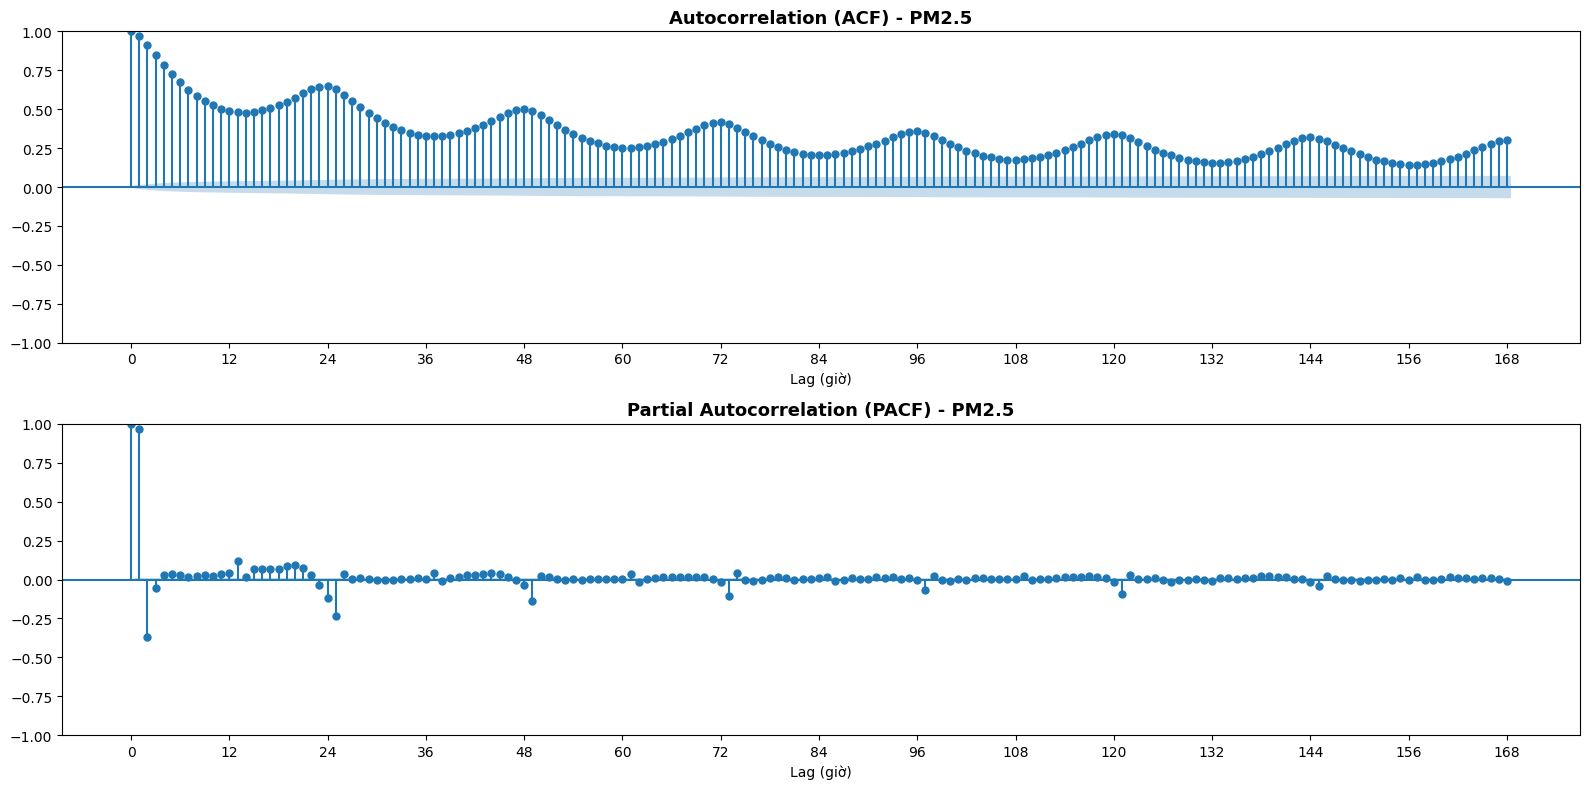

In [47]:
# Sắp xếp theo thời gian để đảm bảo đúng thứ tự chuỗi
df_sorted_acf = df.sort_index()
ts = df_sorted_acf['PM2.5']

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

plot_acf(ts, lags=168, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF) - PM2.5', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lag (giờ)')
axes[0].set_xticks(np.arange(0, 169, 12))

plot_pacf(ts, lags=168, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF) - PM2.5', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Lag (giờ)')
axes[1].set_xticks(np.arange(0, 169, 12))

plt.tight_layout()
plt.show()

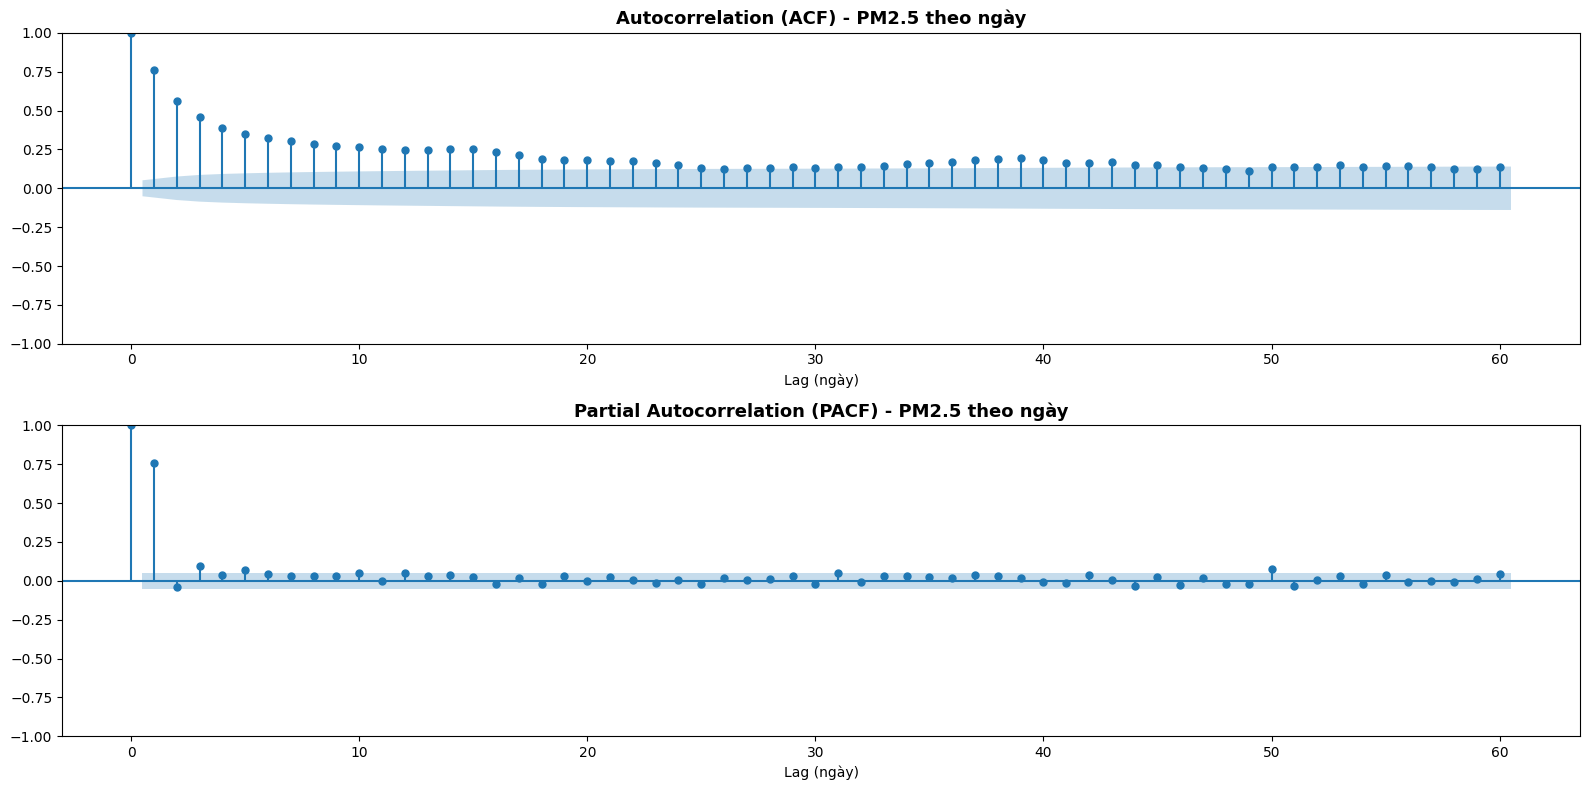

In [48]:
# Sắp xếp theo thời gian, resample về trung bình theo ngày để mỗi lag = 1 ngày (24 giờ)
daily_ts = df.sort_index()['PM2.5'].resample('D').mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

plot_acf(daily_ts, lags=60, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF) - PM2.5 theo ngày', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lag (ngày)')

plot_pacf(daily_ts, lags=60, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF) - PM2.5 theo ngày', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Lag (ngày)')

plt.tight_layout()
plt.show()

##### Time Series Decomposition (Trend + Seasonal + Residual)

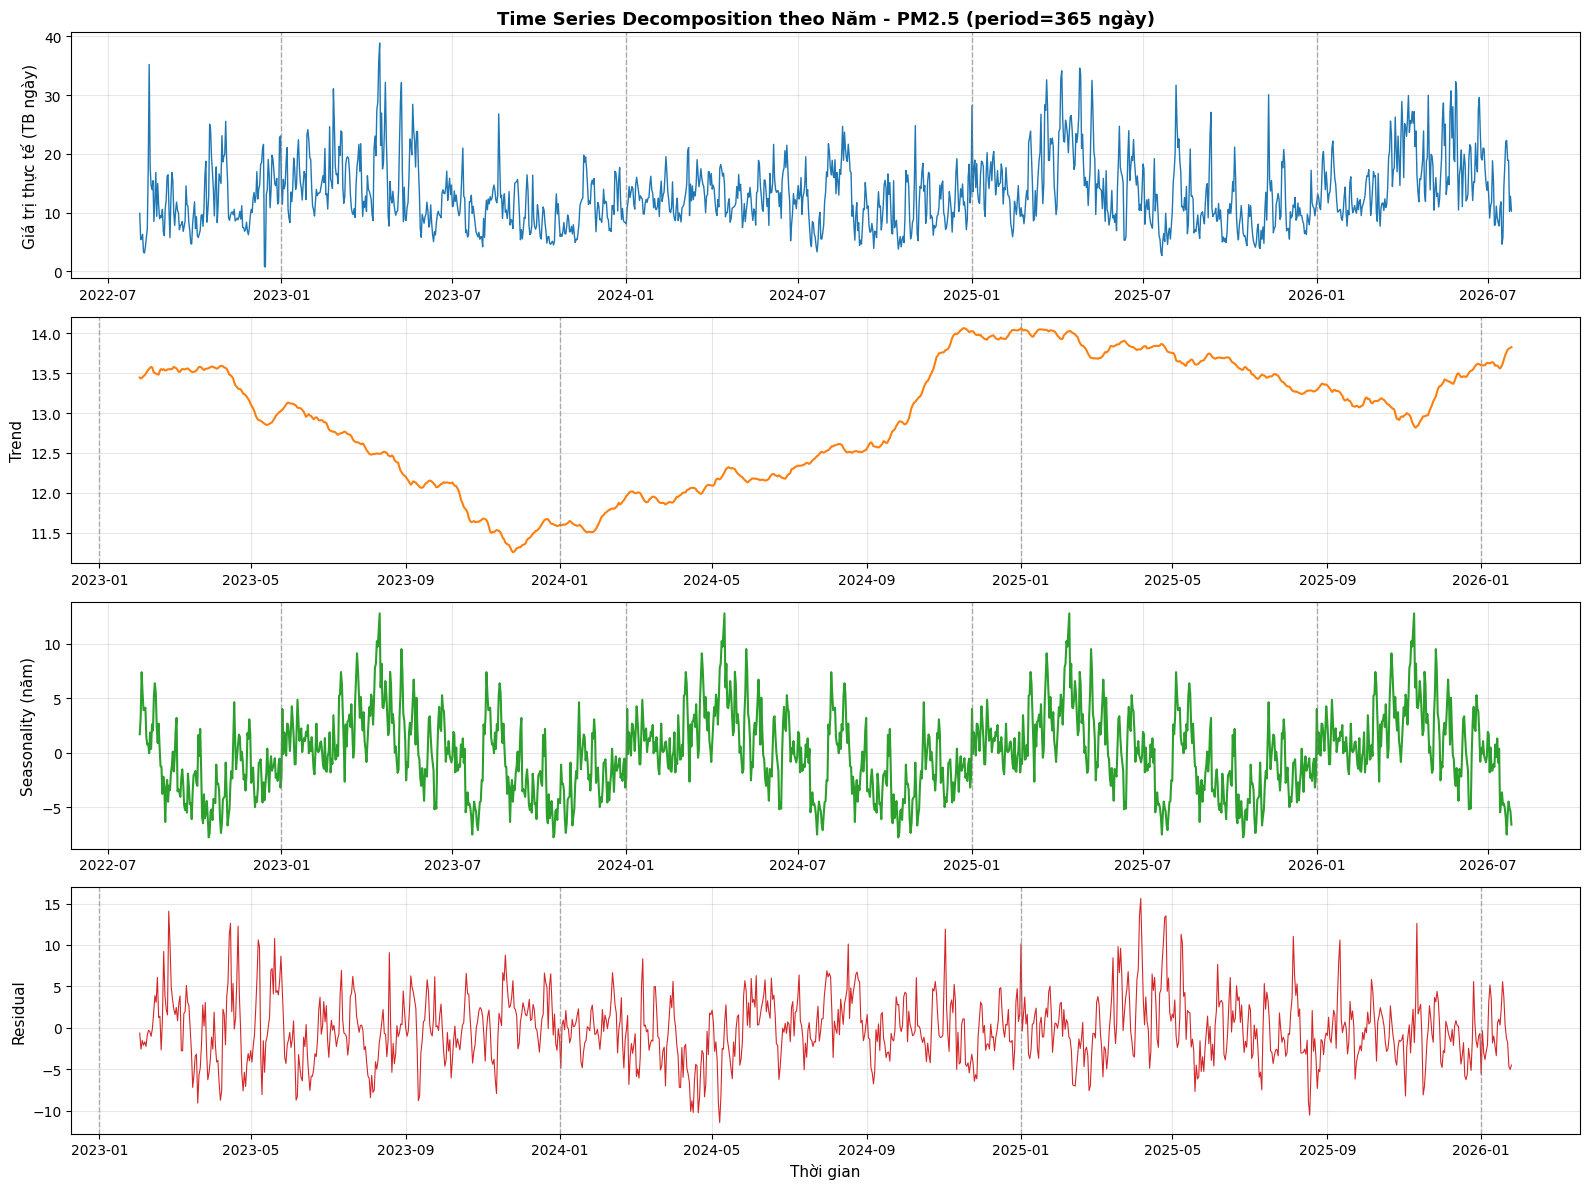

In [49]:
# Decomposition theo chu kỳ NĂM: resample về trung bình ngày, period=365 để bắt seasonality theo mùa/năm
daily_ts_decomp = df_sorted['PM2.5'].resample('D').mean()

decomposition_yearly = seasonal_decompose(daily_ts_decomp, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

axes[0].plot(decomposition_yearly.observed.index, decomposition_yearly.observed.values, color='#1f77b4', linewidth=1)
axes[0].set_ylabel('Giá trị thực tế (TB ngày)', fontsize=11)
axes[0].set_title('Time Series Decomposition theo Năm - PM2.5 (period=365 ngày)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomposition_yearly.trend.index, decomposition_yearly.trend.values, color='#ff7f0e', linewidth=1.5)
axes[1].set_ylabel('Trend', fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomposition_yearly.seasonal.index, decomposition_yearly.seasonal.values, color='#2ca02c', linewidth=1.5)
axes[2].set_ylabel('Seasonality (năm)', fontsize=11)
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomposition_yearly.resid.index, decomposition_yearly.resid.values, color='#d62728', linewidth=0.8)
axes[3].set_ylabel('Residual', fontsize=11)
axes[3].set_xlabel('Thời gian', fontsize=11)
axes[3].grid(True, alpha=0.3)

# Vẽ đường nét đứt đứng để phân biệt ranh giới giữa các năm
year_boundaries = pd.date_range(
    start=f"{daily_ts_decomp.index.min().year}-01-01",
    end=f"{daily_ts_decomp.index.max().year + 1}-01-01",
    freq="YS"
)
for ax in axes:
    xlim = ax.get_xlim()  # lưu lại giới hạn trục X gốc trước khi thêm axvline
    for yb in year_boundaries:
        ax.axvline(yb, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xlim(xlim)  # khôi phục giới hạn gốc để tránh axvline làm giãn trục X

plt.tight_layout()
plt.show()

##### Kiểm tra Residual: ACF & Ljung-Box Test

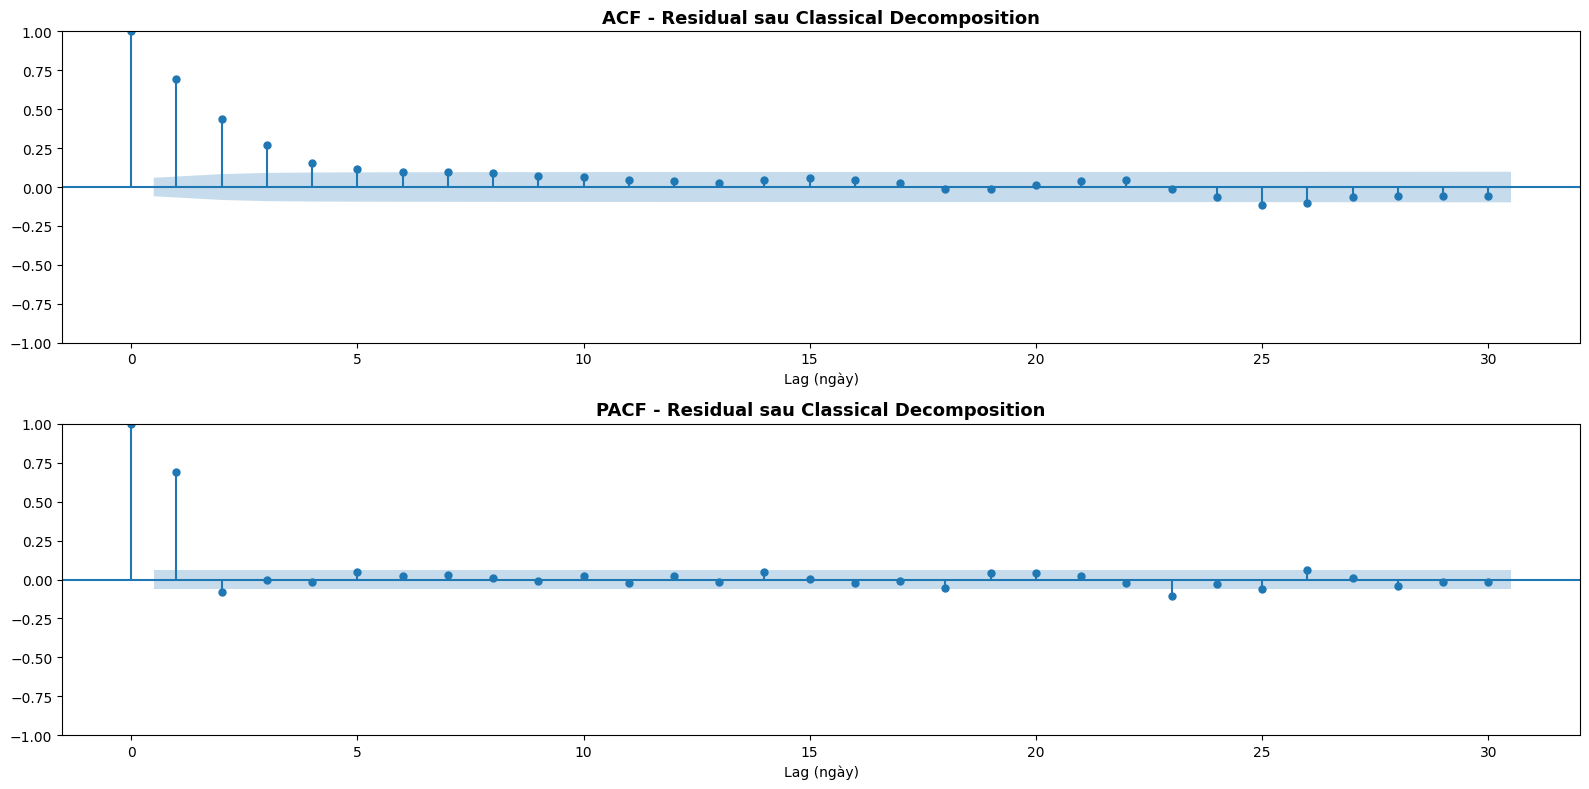

        lb_stat      lb_pvalue
10   889.014140  1.473170e-184
20   902.590910  2.207946e-178
30   953.523711  3.263513e-181
60   976.903329  8.393581e-166
90  1018.554482  3.501447e-157

Kết luận: Còn autocorrelation ở ít nhất 1 lag (bác bỏ H0) -> decomposition chưa tách hết cấu trúc


In [50]:
resid_check = decomposition_yearly.resid.dropna()

# ACF & PACF của Residual: ACF gợi ý bậc MA(q), PACF gợi ý bậc AR(p) nếu muốn model tiếp phần còn lại
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

plot_acf(resid_check, lags=30, ax=axes[0])
axes[0].set_title('ACF - Residual sau Classical Decomposition', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lag (ngày)')

plot_pacf(resid_check, lags=30, ax=axes[1], method='ywm')
axes[1].set_title('PACF - Residual sau Classical Decomposition', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Lag (ngày)')

plt.tight_layout()
plt.show()

# Ljung-Box test: H0 = Residual là white noise (không còn autocorrelation ở các lag kiểm tra)
lb_result = acorr_ljungbox(resid_check, lags=[10, 20, 30, 60, 90], return_df=True)
print(lb_result)
print()
print("Kết luận: " + ("Còn autocorrelation ở ít nhất 1 lag (bác bỏ H0) -> decomposition chưa tách hết cấu trúc"
                       if (lb_result['lb_pvalue'] < 0.05).any()
                       else "Không còn autocorrelation đáng kể (không bác bỏ H0) -> Residual gần với white noise"))

##### Stationarity Test: ADF & KPSS

In [51]:
def stationarity_report(series, name):
    print(f"=== {name} ===")

    adf_result = adfuller(series, autolag='AIC')
    print("ADF Test (H0: không dừng - có unit root)")
    print(f"  ADF statistic: {adf_result[0]:.4f}")
    print(f"  p-value: {adf_result[1]:.4f}")
    print(f"  Kết luận: {'Dừng (bác bỏ H0)' if adf_result[1] < 0.05 else 'Không dừng (không bác bỏ H0)'}")

    kpss_result = kpss(series, regression='c', nlags='auto')
    print("KPSS Test (H0: dừng)")
    print(f"  KPSS statistic: {kpss_result[0]:.4f}")
    print(f"  p-value: {kpss_result[1]:.4f}")
    print(f"  Kết luận: {'Dừng (không bác bỏ H0)' if kpss_result[1] > 0.05 else 'Không dừng (bác bỏ H0)'}")
    print()

# So sánh: chuỗi PM2.5 gốc theo ngày (còn nguyên trend + seasonality) vs Residual sau Classical Decomposition (đã tách hết)
stationarity_report(daily_ts_decomp.dropna(), "PM2.5 gốc (theo ngày)")
stationarity_report(decomposition_yearly.resid.dropna(), "Residual sau Classical Decomposition")

=== PM2.5 gốc (theo ngày) ===
ADF Test (H0: không dừng - có unit root)
  ADF statistic: -7.0323
  p-value: 0.0000
  Kết luận: Dừng (bác bỏ H0)
KPSS Test (H0: dừng)
  KPSS statistic: 0.3714
  p-value: 0.0895
  Kết luận: Dừng (không bác bỏ H0)

=== Residual sau Classical Decomposition ===
ADF Test (H0: không dừng - có unit root)
  ADF statistic: -13.9912
  p-value: 0.0000
  Kết luận: Dừng (bác bỏ H0)
KPSS Test (H0: dừng)
  KPSS statistic: 0.0639
  p-value: 0.1000
  Kết luận: Dừng (không bác bỏ H0)



##### Trực quan hóa Stationarity: Rolling Mean & Rolling Std

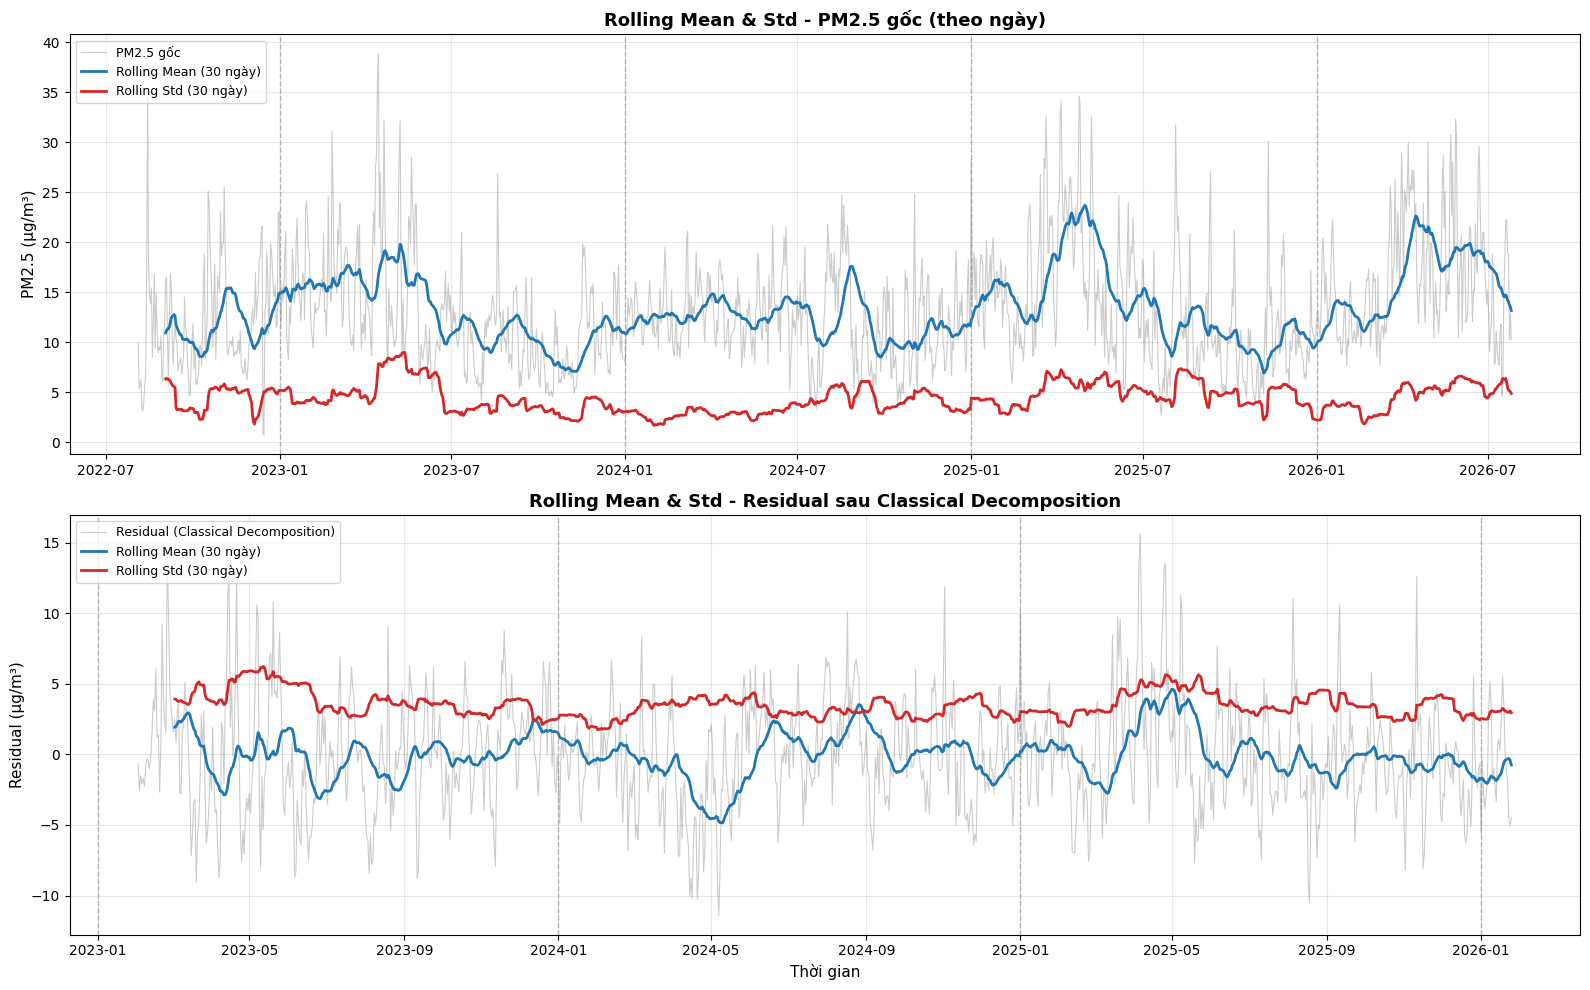

In [52]:
# Nếu mean/std ổn định (không trôi dạt) theo thời gian -> dấu hiệu trực quan của stationary
window = 30  # ngày

raw = daily_ts_decomp.dropna()
resid = decomposition_yearly.resid.dropna()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- PM2.5 gốc ---
roll_mean_raw = raw.rolling(window=window).mean()
roll_std_raw = raw.rolling(window=window).std()

axes[0].plot(raw.index, raw.values, color='gray', alpha=0.4, linewidth=0.8, label='PM2.5 gốc')
axes[0].plot(roll_mean_raw.index, roll_mean_raw.values, color='#1f77b4', linewidth=2, label=f'Rolling Mean ({window} ngày)')
axes[0].plot(roll_std_raw.index, roll_std_raw.values, color='#d62728', linewidth=2, label=f'Rolling Std ({window} ngày)')
axes[0].set_title('Rolling Mean & Std - PM2.5 gốc (theo ngày)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)', fontsize=11)
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Residual sau Classical Decomposition ---
roll_mean_resid = resid.rolling(window=window).mean()
roll_std_resid = resid.rolling(window=window).std()

axes[1].plot(resid.index, resid.values, color='gray', alpha=0.4, linewidth=0.8, label='Residual (Classical Decomposition)')
axes[1].plot(roll_mean_resid.index, roll_mean_resid.values, color='#1f77b4', linewidth=2, label=f'Rolling Mean ({window} ngày)')
axes[1].plot(roll_std_resid.index, roll_std_resid.values, color='#d62728', linewidth=2, label=f'Rolling Std ({window} ngày)')
axes[1].set_title('Rolling Mean & Std - Residual sau Classical Decomposition', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Residual (µg/m³)', fontsize=11)
axes[1].set_xlabel('Thời gian', fontsize=11)
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)

# Đường phân cách năm, đồng bộ style với các cell trước
for ax in axes:
    xlim = ax.get_xlim()
    for yb in year_boundaries:
        ax.axvline(yb, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlim(xlim)

plt.tight_layout()
plt.show()

##### Mann-Kendall Trend Test: Kiểm định thống kê cho xu hướng PM2.5

In [70]:
# Seasonal Mann-Kendall test: kiểm định phi tham số cho xu hướng đơn điệu, xử lý seasonality ngay trong test
# (không cần decompose trước) -> phù hợp để xác nhận thống kê cho xu hướng tăng đã quan sát bằng mắt ở
# Moving Average / Trend component
monthly_pm25 = df_sorted['PM2.5'].resample('MS').mean()
mk_result = mk.seasonal_test(monthly_pm25, period=12)

print("=== Seasonal Mann-Kendall (PM2.5 trung bình theo tháng, period=12) ===")
print(f"Xu hướng: {mk_result.trend}")
print(f"p-value: {mk_result.p:.4f}")
print(f"Sen's slope: {mk_result.slope:.4f} µg/m³/tháng (~{mk_result.slope * 12:.3f} µg/m³/năm)")
print(f"Kết luận: {'Có xu hướng ' + mk_result.trend + ' có ý nghĩa thống kê (bác bỏ H0)' if mk_result.h else 'Không đủ bằng chứng thống kê cho xu hướng (không bác bỏ H0)'}")
print()
print(f"Lưu ý: chỉ có {len(monthly_pm25)} tháng dữ liệu (~4 năm) -> mỗi vị trí tháng chỉ có ~4 lần lặp lại,")
print("test có power thấp -> kết luận 'không có xu hướng' nên hiểu là 'chưa đủ bằng chứng', không phải")
print("'chắc chắn không có xu hướng'.")

=== Seasonal Mann-Kendall (PM2.5 trung bình theo tháng, period=12) ===
Xu hướng: no trend
p-value: 0.2024
Sen's slope: 0.3146 µg/m³/tháng (~3.775 µg/m³/năm)
Kết luận: Không đủ bằng chứng thống kê cho xu hướng (không bác bỏ H0)

Lưu ý: chỉ có 48 tháng dữ liệu (~4 năm) -> mỗi vị trí tháng chỉ có ~4 lần lặp lại,
test có power thấp -> kết luận 'không có xu hướng' nên hiểu là 'chưa đủ bằng chứng', không phải
'chắc chắn không có xu hướng'.


##### Periodogram (FFT): Xác nhận các chu kỳ chiếm ưu thế trong dữ liệu

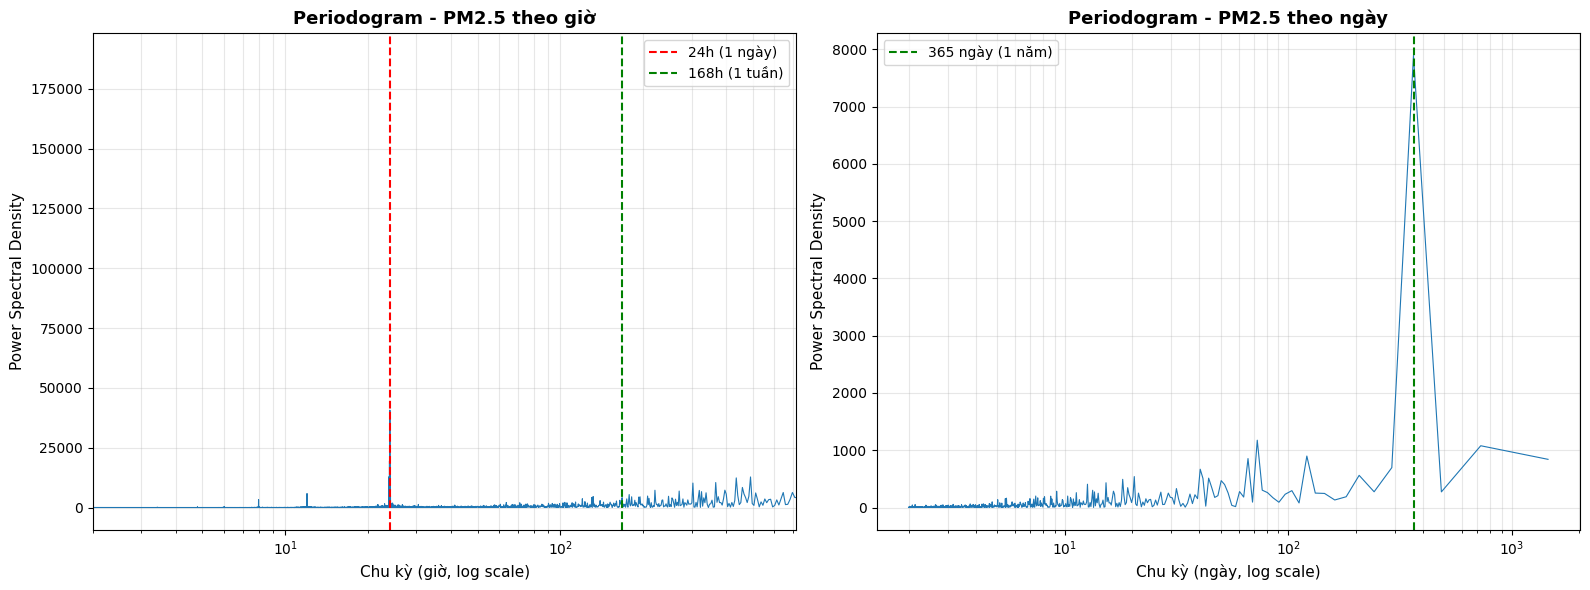

Top chu kỳ nổi bật (dữ liệu theo giờ):
  8716.2h (~363.18 ngày), power=188903.0
  24.0h (~1.00 ngày), power=40683.1
  1743.3h (~72.64 ngày), power=28163.8
  2905.4h (~121.06 ngày), power=21669.5
  1584.8h (~66.03 ngày), power=20525.0

Top chu kỳ nổi bật (dữ liệu theo ngày):
  363.2 ngày (~0.99 năm), power=7892.9
  72.7 ngày (~0.20 năm), power=1175.5
  121.1 ngày (~0.33 năm), power=898.6
  66.0 ngày (~0.18 năm), power=855.0
  290.6 ngày (~0.80 năm), power=696.6

Các đỉnh phụ ở panel theo ngày (72, 121, 66, 40... ngày) đều là ước số của ~365 -> harmonics của
chu kỳ năm (do hình dạng chu kỳ năm không phải sóng sin hoàn hảo), không phải chu kỳ độc lập mới.


In [71]:
# Periodogram: thay vì GIẢ ĐỊNH trước period=24 và period=365, quét phổ tần số để xem đâu mới thực sự
# là (các) chu kỳ mạnh nhất ẩn trong dữ liệu, không cần đoán trước.
from scipy.signal import periodogram


def top_periods(series, fs, n=5):
    freqs, power = periodogram(series.values, fs=fs)
    periods = 1 / freqs[1:]
    power = power[1:]
    max_reliable = len(series) / 3  # chu kỳ dài hơn 1/3 độ dài chuỗi không đủ tin cậy (quá ít lần lặp lại)
    idx = np.argsort(power)[::-1]
    idx = [i for i in idx if periods[i] <= max_reliable][:n]
    return periods, power, [(periods[i], power[i]) for i in idx]


periods_h, power_h, top_h = top_periods(df_sorted['PM2.5'].dropna(), fs=1.0)
periods_d, power_d, top_d = top_periods(daily_ts_decomp.dropna(), fs=1.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(periods_h, power_h, linewidth=0.8, color='#1f77b4')
axes[0].set_xscale('log')
axes[0].set_xlim(2, 24 * 30)
axes[0].axvline(24, color='red', linestyle='--', linewidth=1.5, label='24h (1 ngày)')
axes[0].axvline(168, color='green', linestyle='--', linewidth=1.5, label='168h (1 tuần)')
axes[0].set_xlabel('Chu kỳ (giờ, log scale)', fontsize=11)
axes[0].set_ylabel('Power Spectral Density', fontsize=11)
axes[0].set_title('Periodogram - PM2.5 theo giờ', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, which='both')

axes[1].plot(periods_d, power_d, linewidth=0.8, color='#1f77b4')
axes[1].set_xscale('log')
axes[1].axvline(365.25, color='green', linestyle='--', linewidth=1.5, label='365 ngày (1 năm)')
axes[1].set_xlabel('Chu kỳ (ngày, log scale)', fontsize=11)
axes[1].set_ylabel('Power Spectral Density', fontsize=11)
axes[1].set_title('Periodogram - PM2.5 theo ngày', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("Top chu kỳ nổi bật (dữ liệu theo giờ):")
for p, pw in top_h:
    print(f"  {p:.1f}h (~{p / 24:.2f} ngày), power={pw:.1f}")
print()
print("Top chu kỳ nổi bật (dữ liệu theo ngày):")
for p, pw in top_d:
    print(f"  {p:.1f} ngày (~{p / 365.25:.2f} năm), power={pw:.1f}")
print()
print("Các đỉnh phụ ở panel theo ngày (72, 121, 66, 40... ngày) đều là ước số của ~365 -> harmonics của")
print("chu kỳ năm (do hình dạng chu kỳ năm không phải sóng sin hoàn hảo), không phải chu kỳ độc lập mới.")